In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [4]:
from google.colab import drive

drive.mount('/content/drive')

# Create local folder for exported figures
os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.1)

Mounted at /content/drive


In [5]:
drive_path = '/content/drive/MyDrive/Datasets/churn_dataset.csv'
df = pd.read_csv(drive_path)

In [6]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [7]:
# Drop identifier columns if present
for id_col in ['customerID', 'id', 'ID', 'CustomerId']:
  if id_col in df.columns:
    df = df.drop(columns=[id_col])

# Clean TotalCharges if it contains empty string spaces
if 'TotalCharges' in df.columns:
  df['TotalCharges'] = pd.to_numeric(
      df['TotalCharges'].astype(str).str.strip(), errors='coerce'
  )

# Encode Churn target (Yes/No -> 1/0)
if df['Churn'].dtype == 'object':
  df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [8]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [9]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [11]:
num_transformer = Pipeline(
    [('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]
)

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols),
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Extract feature names
cat_features = (
    preprocessor.named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_feature_names = num_cols + cat_features

# Clean feature labels for plot readability
clean_feature_names = [
    f.replace('Contract_', 'Contract: ')
    .replace('TechSupport_', 'TechSupport: ')
    .replace('InternetService_', 'Internet: ')
    for f in all_feature_names
]

In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=100, learning_rate=0.1, eval_metric='logloss', random_state=42
    ),
    'SVM': SVC(probability=True, kernel='rbf', random_state=42),
}

In [13]:
results = []
fitted_models = {}

for name, model in models.items():
  model.fit(X_train_prep, y_train)
  fitted_models[name] = model

  y_pred = model.predict(X_test_prep)
  y_proba = model.predict_proba(X_test_prep)[:, 1]

  results.append({
      'Model': name,
      'Accuracy': accuracy_score(y_test, y_pred),
      'Precision': precision_score(y_test, y_pred, zero_division=0),
      'Recall': recall_score(y_test, y_pred, zero_division=0),
      'F1-Score': f1_score(y_test, y_pred, zero_division=0),
      'ROC-AUC': roc_auc_score(y_test, y_proba),
  })

df_results = pd.DataFrame(results)

In [14]:
df_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Random Forest,0.777857,0.603390,0.475936,0.532138,0.816159
2,XGBoost,0.796309,0.638978,0.534759,0.582242,0.836907
3,SVM,0.791341,0.641844,0.483957,0.551829,0.790506


In [16]:
# --- CHART 1: FEATURE IMPORTANCES ---
xgb_model = fitted_models['XGBoost']
importances = xgb_model.feature_importances_

df_imp = (
    pd.DataFrame({'Feature': clean_feature_names, 'Importance': importances})
    .sort_values(by='Importance', ascending=False)
    .head(5)
)

plt.figure(figsize=(8, 4.5))
sns.barplot(
    data=df_imp,
    x='Importance',
    y='Feature',
    palette='viridis',
    hue='Feature',
    legend=False,
)
plt.title(
    'Figure 1: Top Feature Importances in Churn Prediction', fontsize=14, pad=12
)
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)

max_imp = df_imp['Importance'].max()
plt.xlim(0, max_imp * 1.25)

for index, row in enumerate(df_imp.itertuples()):
  plt.text(
      row.Importance + (max_imp * 0.02),
      index,
      f'{row.Importance:.2f}',
      va='center',
      fontsize=10,
  )

plt.tight_layout()
plt.savefig('figures/chart1_feature_importance.png', dpi=300)
plt.close()

In [18]:
df_melted = pd.melt(
    df_results[['Model', 'Accuracy', 'F1-Score', 'ROC-AUC']],
    id_vars=['Model'],
    var_name='Metric',
    value_name='Score',
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_melted, x='Model', y='Score', hue='Metric', palette='Blues_d'
)
plt.title(
    'Figure 2: Classification Performance Across Evaluated Models',
    fontsize=14,
    pad=12,
)
plt.xlabel('Machine Learning Algorithm', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0.0, 1.05)
plt.legend(title='Metric', loc='lower right')

plt.tight_layout()
plt.savefig('figures/chart2_model_comparison.png', dpi=300)
plt.close()

print('✅ Experiment Completed!')
print('\n--- MODEL PERFORMANCE ---')
print(df_results.to_string(index=False))
print('\n--- TOP 5 FEATURE IMPORTANCES ---')
print(df_imp.to_string(index=False))

✅ Experiment Completed!

--- MODEL PERFORMANCE ---
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.805536   0.657233 0.558824  0.604046 0.841861
      Random Forest  0.777857   0.603390 0.475936  0.532138 0.816159
            XGBoost  0.796309   0.638978 0.534759  0.582242 0.836907
                SVM  0.791341   0.641844 0.483957  0.551829 0.790506

--- TOP 5 FEATURE IMPORTANCES ---
                 Feature  Importance
Contract: Month-to-month    0.463376
   Internet: Fiber optic    0.279707
       OnlineSecurity_No    0.017379
           Internet: DSL    0.017146
     StreamingMovies_Yes    0.016593


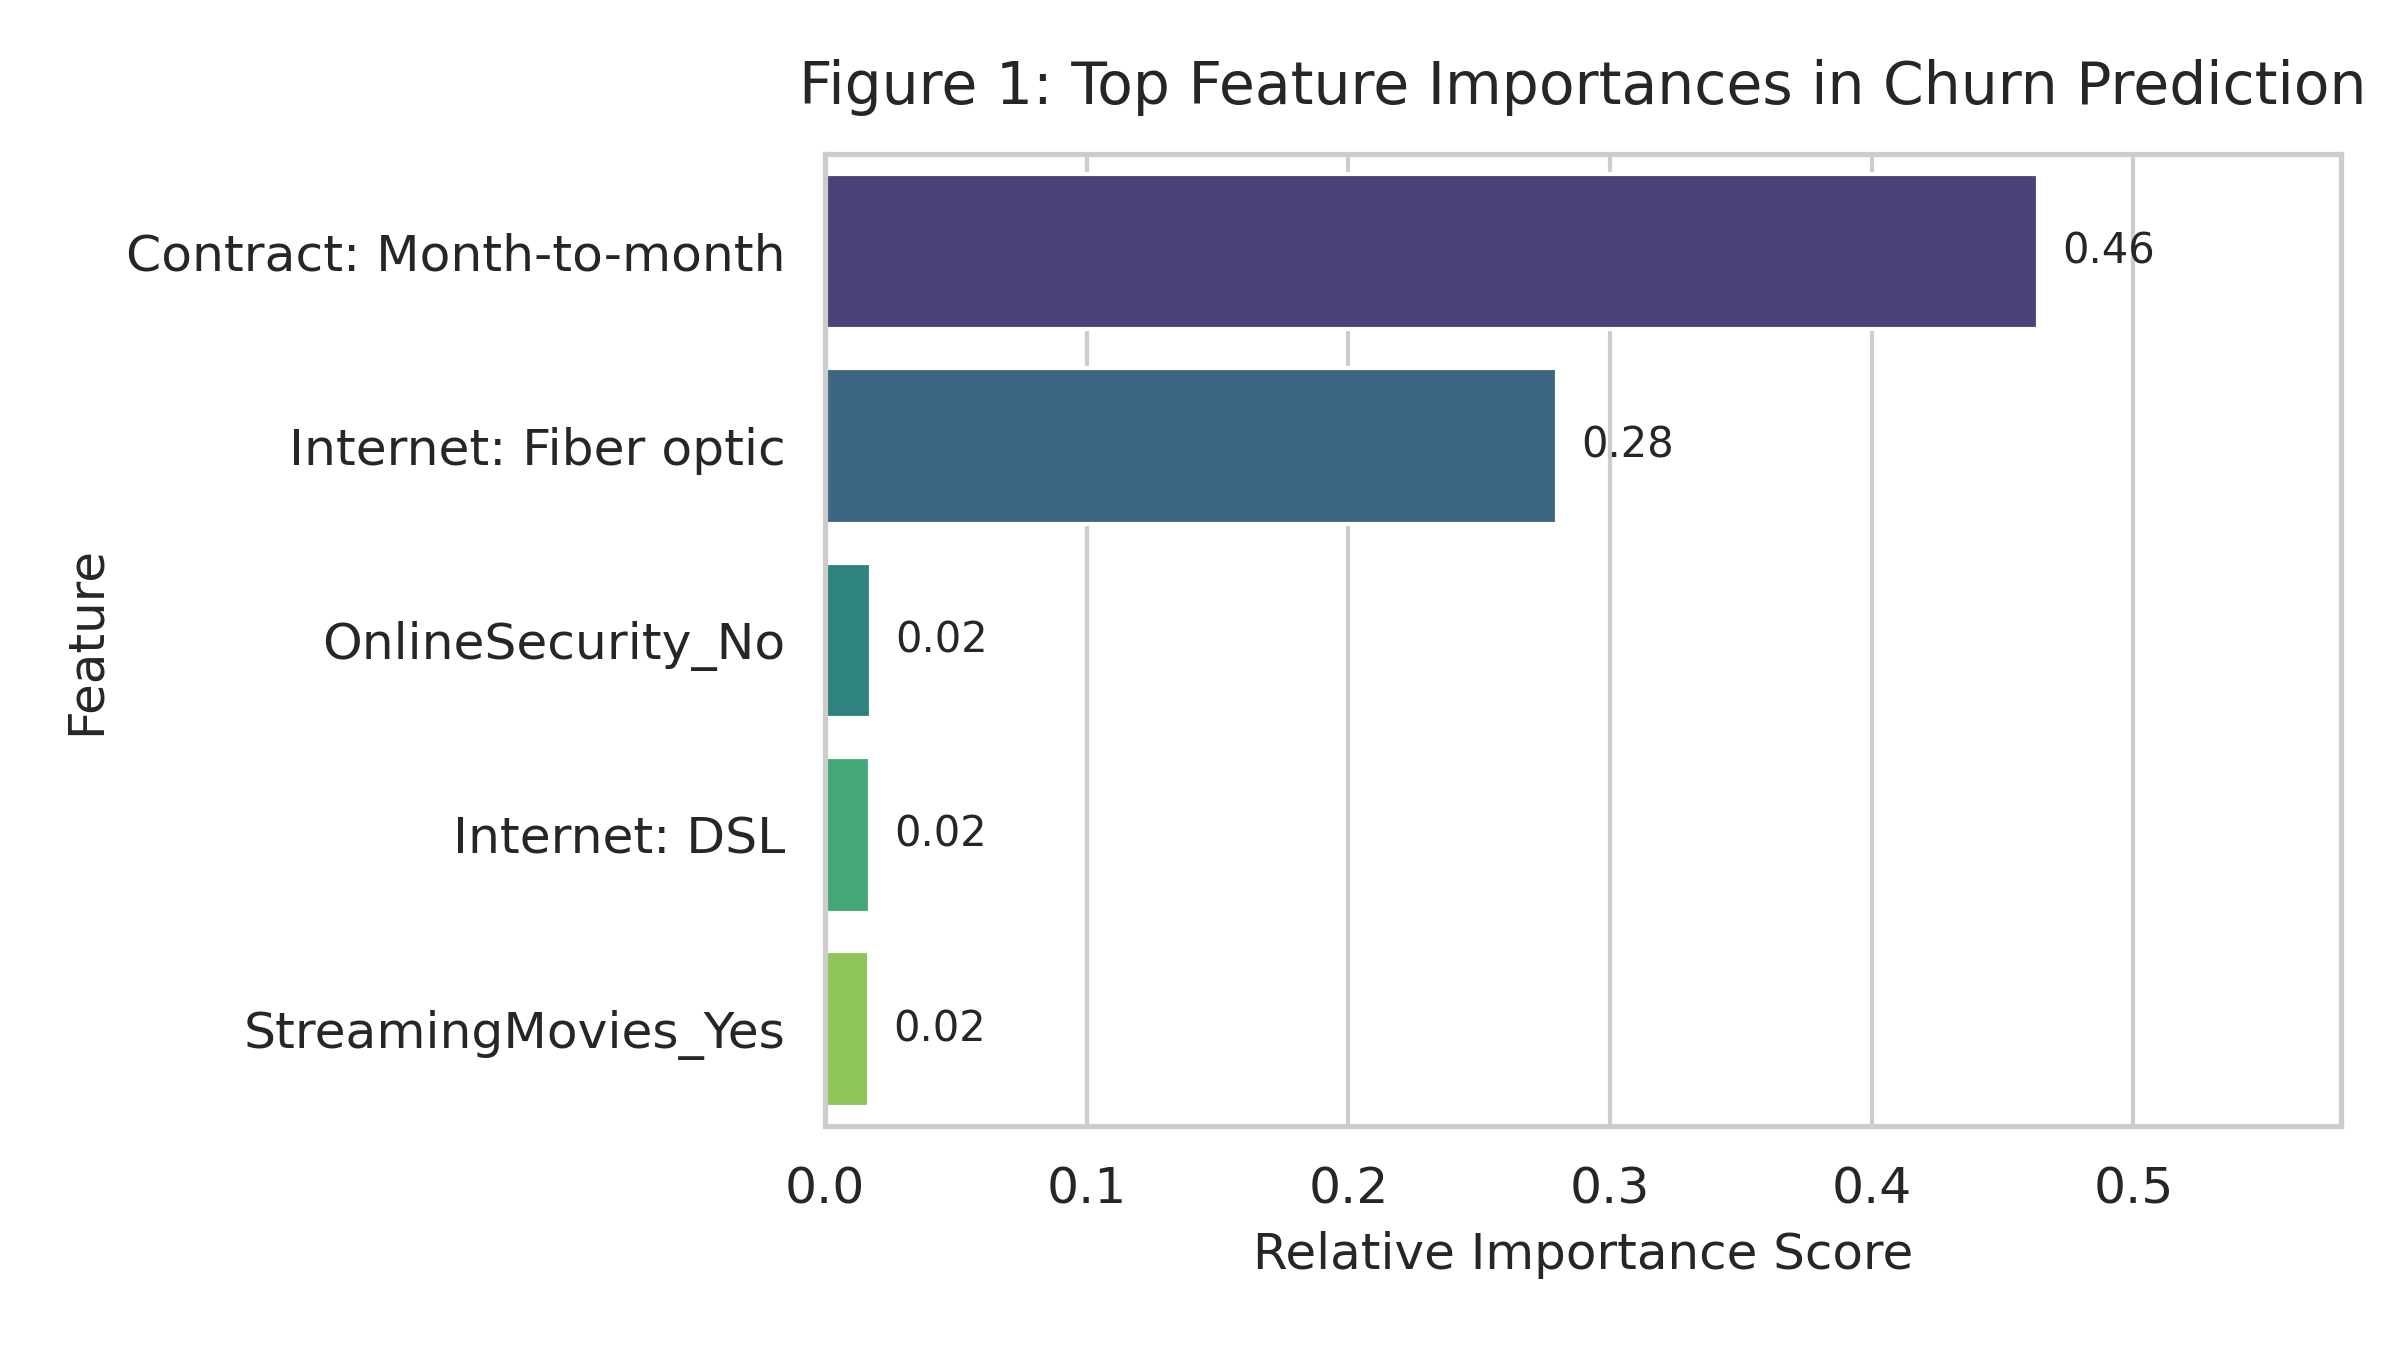

In [21]:
from IPython.display import Image, display

display(Image("figures/chart1_feature_importance.png"))


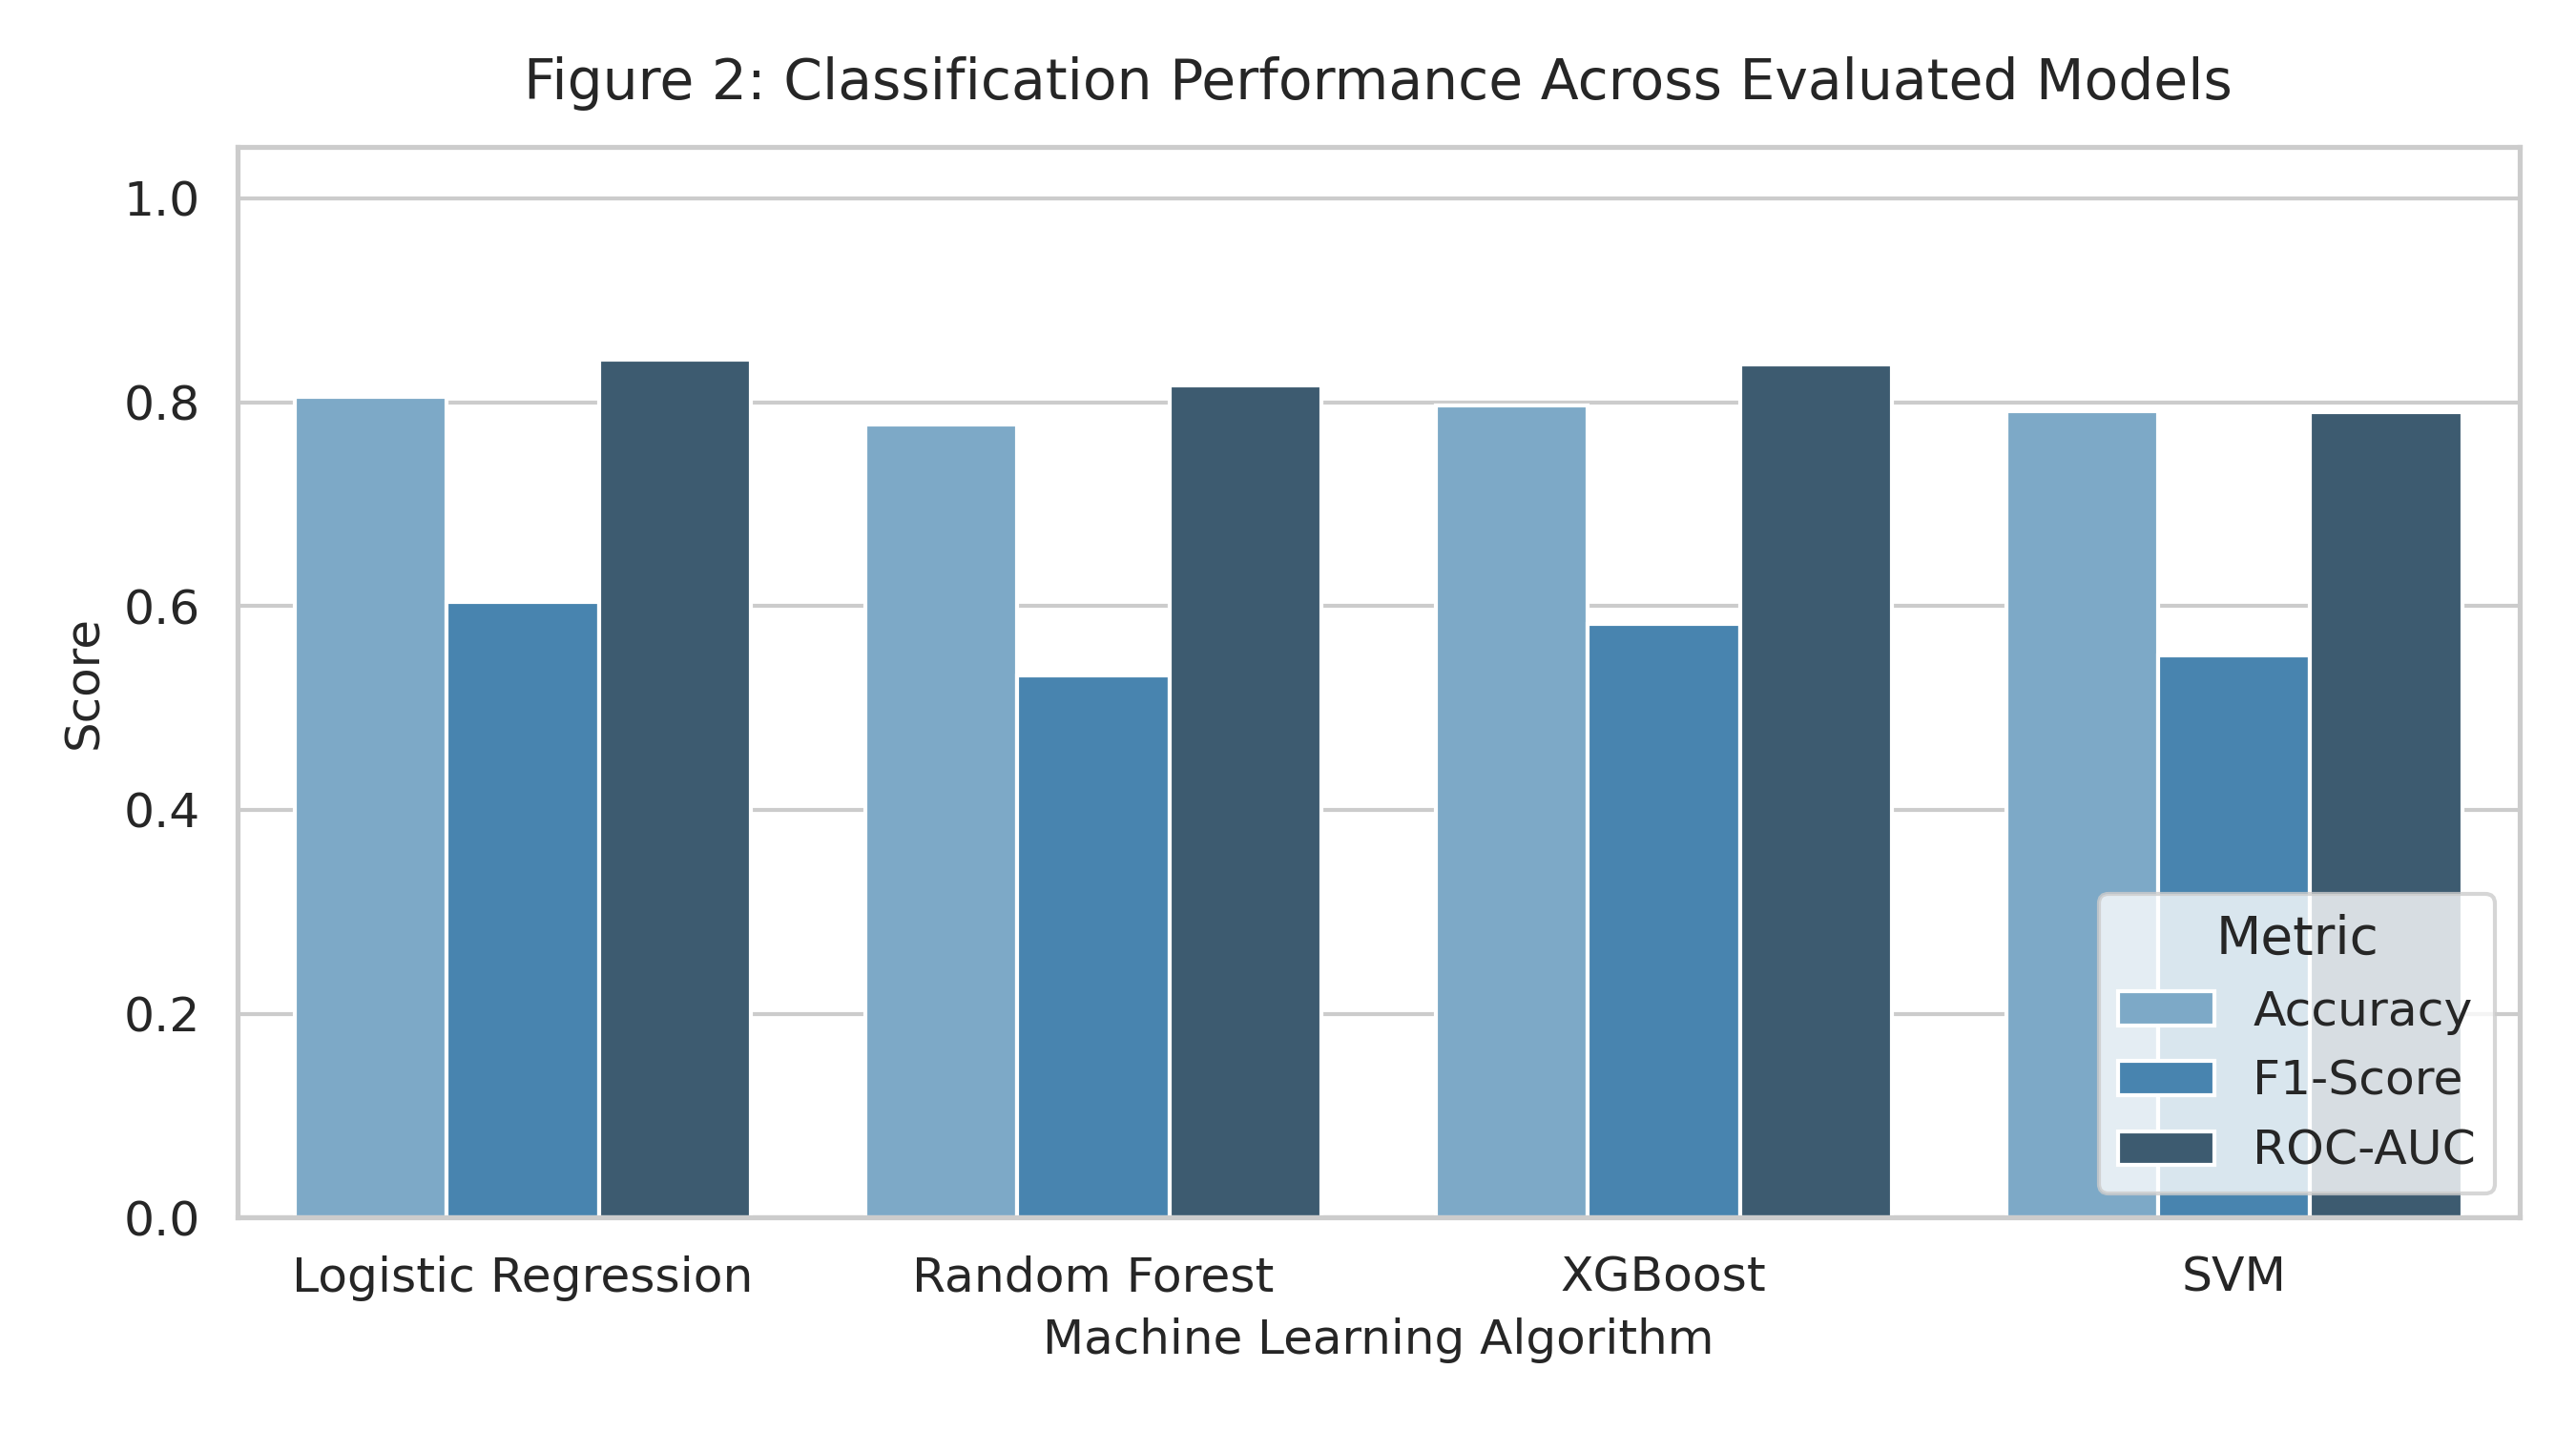

In [20]:
display(Image("figures/chart2_model_comparison.png"))

In [22]:
import shutil
from google.colab import files

# Zip the figures folder
shutil.make_archive('figures', 'zip', 'figures')

# Download the zipped figures
files.download('figures.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>